# Análise WDI e PCA - Período da Pandemia (2019 a 2023)
**Objetivo:** Consumir, limpar e processar o dataset de Indicadores de Desenvolvimento Global (WDI), aplicando engenharia de features e redução de dimensionalidade (PCA) sem uso de bibliotecas de IA.

Nesta primeira etapa, selecionamos colunas englobando os pilares Econômico, Saúde, Educação/Social e Ambiental. Estamos utilizando o dataset previamente agrupado pela média de 2019 a 2023 (`WDICSV_preparado.csv`). Filtramos para remover regiões agregadas (mantendo apenas países) e imputamos os valores nulos com a mediana da feature.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pca # Módulo local fornecido na atividade

# Carregando os datasets
df_data = pd.read_csv('WDICSV_preparado.csv')
paises_dict = pd.read_csv('WDICountry.csv')

# Seleção de Atributos cobrindo todos os pilares (12 features + População)
features_de_interesse = [
    'GDP per capita (constant 2015 US$)',
    'Exports of goods and services (% of GDP)',
    'Final consumption expenditure (current US$)',
    'Life expectancy at birth, total (years)',
    'Mortality rate, under-5 (per 1,000 live births)',
    'Current health expenditure per capita (current US$)',
    'Individuals using the Internet (% of population)',
    'Urban population (% of total population)',
    'School enrollment, primary (% gross)',
    'Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)',
    'Renewable energy consumption (% of total final energy consumption)',
    'Electric power consumption (kWh per capita)',
    'Population, total'
]

# Filtrar o dataset apenas para as colunas desejadas e remover as regiões agregadas
data_reduzida = df_data[['Country Code', 'Country Name'] + features_de_interesse].copy()
regioes = paises_dict[(paises_dict['Region'].isna()) | (paises_dict['Region'] == '')]['Country Code']
data_reduzida = data_reduzida[~data_reduzida['Country Code'].isin(regioes)]
data_pivotada = data_reduzida.set_index(['Country Code', 'Country Name'])

# Tratamento de valores faltantes preenchendo com a mediana
for feat in features_de_interesse:
    data_pivotada[feat] = data_pivotada[feat].fillna(data_pivotada[feat].median())

print(f"Dataset processado: {data_pivotada.shape[0]} países e {data_pivotada.shape[1]} features.")

Dataset processado: 218 países e 13 features.


## Questão 01: Interpretação do PCA
Abaixo aplicamos a normalização z-score e executamos o algoritmo PCA fornecido pelo professor via SVD. Avaliando os pesos (loadings) do Componente Principal 1, identificamos sua síntese de representação.

--- Pesos do Componente Principal 1 ---


,Feature Original,Peso Real (Loading),Importância Absoluta
6,Individuals using the Internet (% of population),-0.398502,0.398502
3,"Life expectancy at birth, total (years)",-0.394774,0.394774
4,"Mortality rate, under-5 (per 1,000 live births)",0.353266,0.353266
7,Urban population (% of total population),-0.322204,0.322204
0,GDP per capita (constant 2015 US$),-0.316226,0.316226


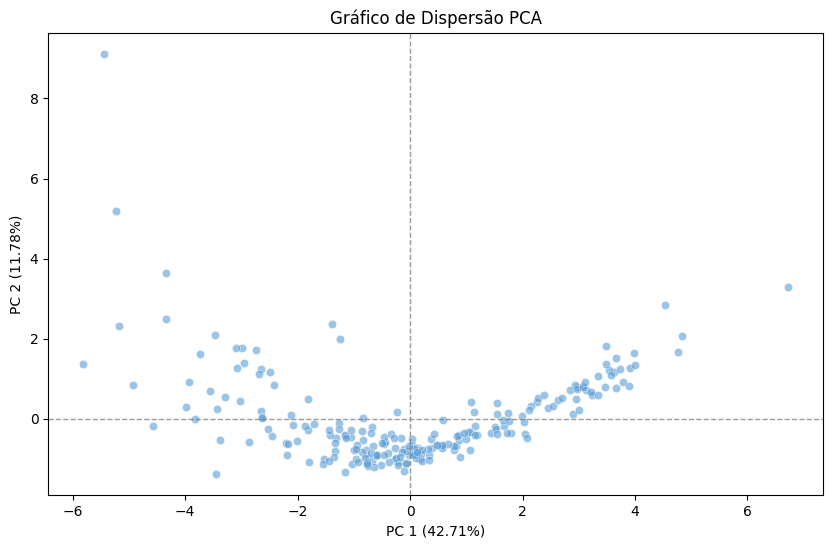

In [15]:
# Isolando as features para o PCA (ignorando a População Total, que será usada na questão 4)
features_pca = [f for f in features_de_interesse if f != 'Population, total']
data_pca = data_pivotada[features_pca].copy()

# Normalização Z-score
data_pca_norm = (data_pca - data_pca.mean()) / data_pca.std()

# Aplicação do PCA
componentes, var_explicada = pca.pca_svd(data_pca_norm)
reduzido = pca.aplica_pca(data_pca_norm, componentes, 2)
df_reduzido = pd.DataFrame(reduzido.values if hasattr(reduzido, 'values') else reduzido,
                           index=data_pca.index, columns=['PC1', 'PC2'])

# Questão 01 - Análise de Pesos
cp1 = componentes[:, 0]
df_importancia = pd.DataFrame({
    'Feature Original': features_pca,
    'Peso Real (Loading)': cp1,
    'Importância Absoluta': np.abs(cp1)
}).sort_values(by='Importância Absoluta', ascending=False)

print("--- Pesos do Componente Principal 1 ---")
display(df_importancia.head(5))

# Plot do PCA
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_reduzido['PC1'], y=df_reduzido['PC2'], alpha=0.6, edgecolor='w', color='#5a9dd6')
plt.xlabel(f"PC 1 ({var_explicada[0]:.2%})")
plt.ylabel(f"PC 2 ({var_explicada[1]:.2%})")
plt.title("Gráfico de Dispersão PCA")
plt.axhline(0, color='grey', lw=1, ls='--', alpha=0.8)
plt.axvline(0, color='grey', lw=1, ls='--', alpha=0.8)
plt.show()

## Questão 02: Criação de Índice de Eficiência de Saúde
Vamos criar a feature `Eficiencia_Saude`, que é a razão entre a expectativa de vida e os gastos com saúde.

In [16]:
data_pivotada['Eficiencia_Saude'] = data_pivotada['Life expectancy at birth, total (years)'] / data_pivotada['Current health expenditure per capita (current US$)']

top_eficiencia = data_pivotada['Eficiencia_Saude'].sort_values(ascending=False).head()
print("--- Top 5 Países em Eficiência de Saúde ---")
print(top_eficiencia)

--- Top 5 Países em Eficiência de Saúde ---
Country Code  Country Name      
MDG           Madagascar            3.811273
SOM           Somalia, Fed. Rep.    3.557329
COD           Congo, Dem. Rep.      2.780940
SDN           Sudan                 2.656741
BDI           Burundi               2.502281
Name: Eficiencia_Saude, dtype: float64


## Questão 03: Binarização e Categorização (Discretização)
Criação da variável categórica `Nivel_Industrial` baseada em quartis para colorir o gráfico PCA.

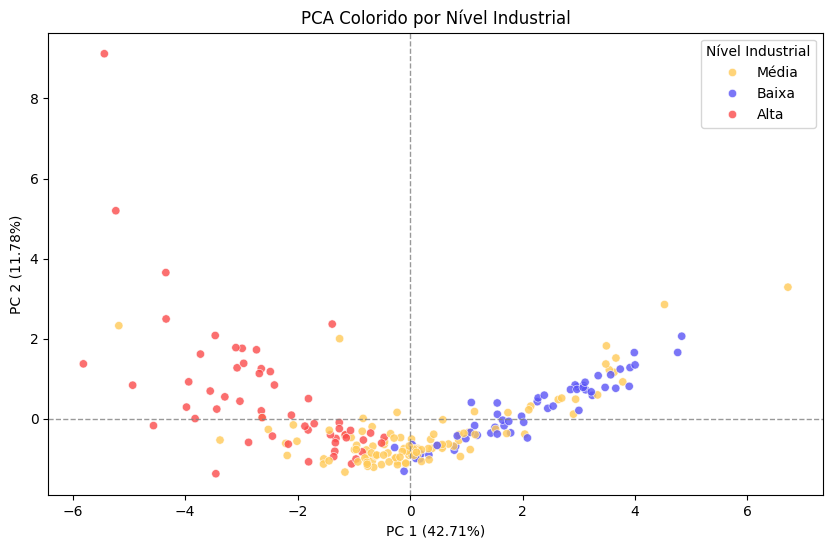

In [17]:
soma_ind = data_pivotada['Exports of goods and services (% of GDP)'] + data_pivotada['Electric power consumption (kWh per capita)']
p75 = soma_ind.quantile(0.75)
p25 = soma_ind.quantile(0.25)

def classificar_industria(val):
    if val > p75: return 'Alta'
    elif val < p25: return 'Baixa'
    else: return 'Média'

data_pivotada['Nivel_Industrial'] = soma_ind.apply(classificar_industria)

cores = {'Alta': '#fb4b4b', 'Média': '#ffca58', 'Baixa': '#5a54f6'}
plt.figure(figsize=(10, 6))

sns.scatterplot(x=df_reduzido['PC1'], y=df_reduzido['PC2'],
                hue=data_pivotada['Nivel_Industrial'],
                palette=cores, alpha=0.8, edgecolor='w')

plt.xlabel(f"PC 1 ({var_explicada[0]:.2%})")
plt.ylabel(f"PC 2 ({var_explicada[1]:.2%})")
plt.title("PCA Colorido por Nível Industrial")
plt.legend(title="Nível Industrial")
plt.axhline(0, color='grey', lw=1, ls='--', alpha=0.8)
plt.axvline(0, color='grey', lw=1, ls='--', alpha=0.8)
plt.show()

## Questão 04: Normalização Condicional
Ajustando os valores absolutos do 'Consumo Total' pelo tamanho da população.

In [18]:
df_norm_cond = data_pivotada.copy()

# Transformando consumo total em per capita[cite: 1]
df_norm_cond['Final consumption expenditure (current US$)'] = df_norm_cond['Final consumption expenditure (current US$)'] / df_norm_cond['Population, total']

data_pca_cond = df_norm_cond[features_pca].copy()
data_pca_cond_norm = (data_pca_cond - data_pca_cond.mean()) / data_pca_cond.std()

comp_cond, var_exp_cond = pca.pca_svd(data_pca_cond_norm)

print(f"Variância explicada pelo PC1 Antes da Normalização Per Capita: {var_explicada[0]:.2%}")
print(f"Variância explicada pelo PC1 Depois da Normalização Per Capita: {var_exp_cond[0]:.2%}")

Variância explicada pelo PC1 Antes da Normalização Per Capita: 42.71%
Variância explicada pelo PC1 Depois da Normalização Per Capita: 42.41%


## Questão 05: Tratamento de Skewness (Assimetria)
Aplicação da transformação logarítmica para atenuar a cauda longa do PIB.

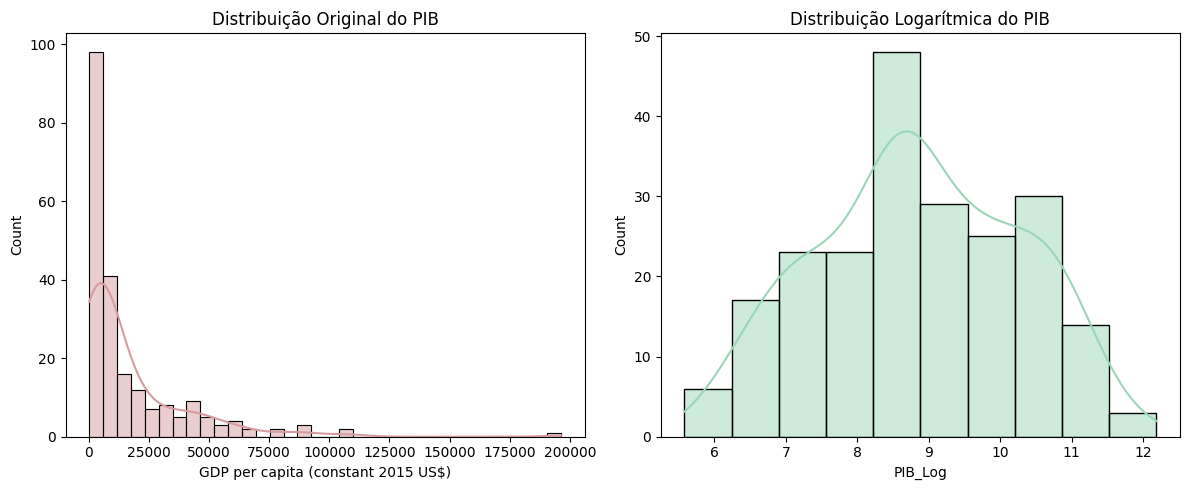

In [19]:
plt.figure(figsize=(12, 5))

# Histograma Original
plt.subplot(1, 2, 1)
sns.histplot(data_pivotada['GDP per capita (constant 2015 US$)'], kde=True, color='#d69c9f')
plt.title("Distribuição Original do PIB")

# Histograma Transformado (Log)
data_pivotada['PIB_Log'] = np.log(data_pivotada['GDP per capita (constant 2015 US$)'])
plt.subplot(1, 2, 2)
sns.histplot(data_pivotada['PIB_Log'], kde=True, color='#9cd6b8')
plt.title("Distribuição Logarítmica do PIB")

plt.tight_layout()
plt.show()